# Notebook 04 — Merge, Feature Engineering & Crisis Score
## Early Warning System Krisis Pariwisata Bali

Notebook gabungan dari **NB04_2** (External Risk Feature Engineering) dan **NB04_1** (Merge + Crisis Score).

**Urutan eksekusi wajib dijaga** — Section 1 (NB04_2) harus selesai sebelum Section 2+ (NB04_1) karena
NB04_1 memuat `combined_additional_features_engineered_new.csv` yang dihasilkan di Section 1.

### Alur Kerja
1. **Section 0** — Setup & Import
2. **Section 1** — External Risk Feature Engineering (konten NB04_2)
3. **Section 2** — Load Semua Data Processed
4. **Section 3** — Sinkronisasi Timeline & Merge
5. **Section 4** — Feature Engineering
6. **Section 5** — Normalisasi Fitur
7. **Section 6** — Hitung Crisis Score
8. **Section 7** — Visualisasi
9. **Section 8** — Simpan Dataset Final
10. **Section 9** — Summary & Statistik Akhir

**Output:** `data/final/crisis_dataset_final.csv` + `data/final/master_dataset_clean.parquet`


## Section 0 — Setup & Import


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import os
import shutil
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../data/final', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)

print('✓ Library siap')


✓ Library siap


## Section 1 — External Risk Feature Engineering
> Konten dari NB04_2. **Harus selesai dijalankan sebelum Section 2** karena
> menghasilkan `combined_additional_features_engineered_new.csv` yang dimuat di Section 2.


### 1.1 Load Data


In [28]:
# Load combined_additional_features dari NB02 Section 6
df_ext = pd.read_csv('../data/processed/combined_additional_features_new.csv')
df_ext['date'] = pd.to_datetime(df_ext['date'])
df_ext = df_ext.sort_values('date').reset_index(drop=True)

print(f'Shape: {df_ext.shape}')
print(f'Date range: {df_ext["date"].min()} → {df_ext["date"].max()}')
print(f'\nKolom tersedia ({len(df_ext.columns)}):')
print(df_ext.columns.tolist())


Shape: (204, 31)
Date range: 2009-01-01 00:00:00 → 2025-12-01 00:00:00

Kolom tersedia (31):
['date', 'gdelt_crisis_score', 'avg_tone', 'risk_ratio', 'trend_composite', 'trend_risk_score', 'trend_drop_flag', 'economic_index', 'economic_risk_score', 'eq_count', 'eq_max_magnitude', 'eq_seismic_energy', 'eq_risk_score', 'wx_precip_sum', 'wx_humidity_mean', 'bmkg_max_magnitude_30d', 'bmkg_seismic_energy', 'earthquake_count', 'earthquake_count_m5_plus', 'pvmbg_volcano_status', 'volcano_status_agung', 'volcano_status_batur', 'bmkg_extreme_weather_days', 'weather_max_rain', 'weather_max_wind_speed', 'weather_max_wind_gust', 'weather_max_temperature', 'eq_count_log', 'eq_m5plus_log', 'rain_log', 'disaster_risk_score']


### 1.2 Eksplorasi 4 Risk Scores Utama


=== Distribusi Risk Scores ===
       gdelt_crisis_score  economic_risk_score  disaster_risk_score  \
count            204.0000             204.0000             204.0000   
mean               0.3102               0.2837               0.1419   
std                0.1515               0.2152               0.1023   
min                0.0141               0.0000               0.0131   
25%                0.1774               0.2024               0.0463   
50%                0.3620               0.2264               0.1326   
75%                0.4329               0.3516               0.1972   
max                0.6754               1.0000               0.5241   

       trend_risk_score  
count          204.0000  
mean             0.4711  
std              0.2427  
min              0.0000  
25%              0.2997  
50%              0.4473  
75%              0.6350  
max              1.0000  


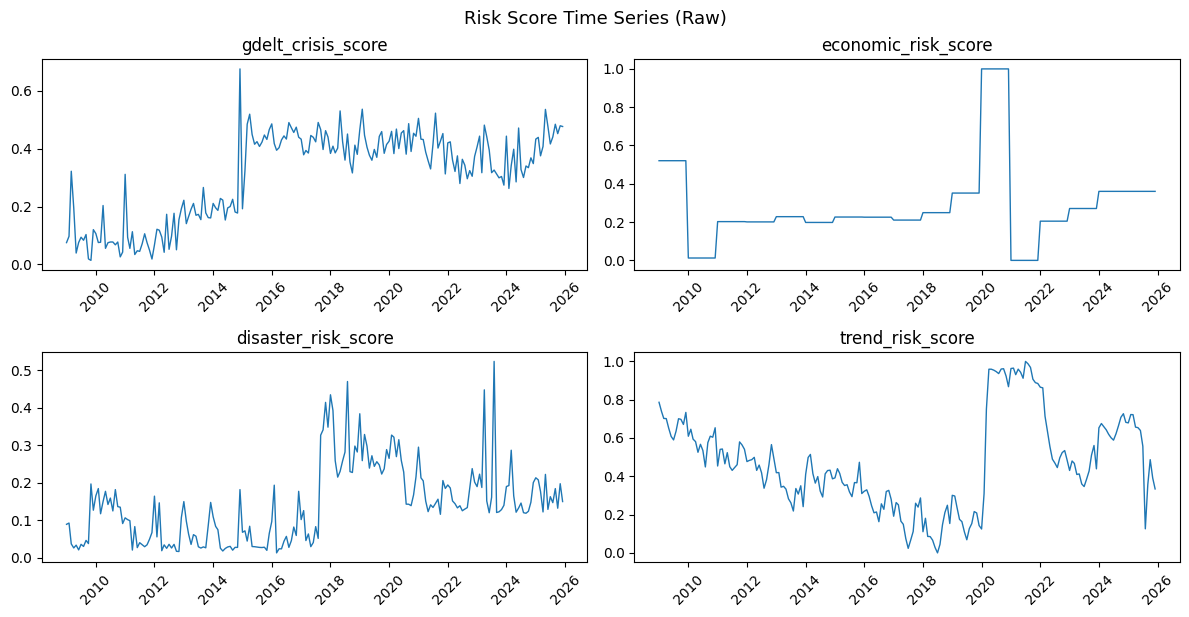

In [29]:
risk_cols = ['gdelt_crisis_score', 'economic_risk_score',
             'disaster_risk_score', 'trend_risk_score']

print('=== Distribusi Risk Scores ===')
print(df_ext[risk_cols].describe().round(4))

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, col in zip(axes.flatten(), risk_cols):
    ax.plot(df_ext['date'], df_ext[col], linewidth=1)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.suptitle('Risk Score Time Series (Raw)', y=1.02, fontsize=13)
plt.show()


### 1.3 Rolling Features (MA3 + Slope 3m)


In [30]:
rolling_targets = ['gdelt_crisis_score', 'disaster_risk_score', 'economic_risk_score']

def rolling_slope_ext(series, window=3):
    """Hitung slope linear regression rolling window."""
    slopes = [np.nan] * len(series)
    for i in range(window - 1, len(series)):
        y = series[i - window + 1 : i + 1].values
        x = np.arange(window)
        slope, _, _, _, _ = stats.linregress(x, y)
        slopes[i] = slope
    return slopes

for col in rolling_targets:
    df_ext[f'{col}_ma3'] = df_ext[col].rolling(window=3, min_periods=1).mean()
    df_ext[f'{col}_slope3m'] = rolling_slope_ext(df_ext[col], window=3)

new_rolling = [c for c in df_ext.columns if '_ma3' in c or '_slope3m' in c]
print('Rolling features dibuat:', new_rolling)
print(f'\nNull dari slope (wajar di awal):')
print(df_ext[new_rolling].isnull().sum())


Rolling features dibuat: ['gdelt_crisis_score_ma3', 'gdelt_crisis_score_slope3m', 'disaster_risk_score_ma3', 'disaster_risk_score_slope3m', 'economic_risk_score_ma3', 'economic_risk_score_slope3m']

Null dari slope (wajar di awal):
gdelt_crisis_score_ma3         0
gdelt_crisis_score_slope3m     2
disaster_risk_score_ma3        0
disaster_risk_score_slope3m    2
economic_risk_score_ma3        0
economic_risk_score_slope3m    2
dtype: int64


### 1.4 Z-score Anomali (Rolling Window 12 Bulan)


In [31]:
zscore_targets = ['gdelt_crisis_score', 'disaster_risk_score']

def rolling_zscore(series, window=12):
    roll_mean = series.rolling(window=window, min_periods=6).mean()
    roll_std  = series.rolling(window=window, min_periods=6).std()
    z = (series - roll_mean) / roll_std.replace(0, np.nan)
    return z

for col in zscore_targets:
    df_ext[f'{col}_zscore'] = rolling_zscore(df_ext[col], window=12)

zscore_cols = [c for c in df_ext.columns if '_zscore' in c]
print('Z-score features dibuat:', zscore_cols)
print()
print(df_ext[zscore_cols].describe().round(3))


Z-score features dibuat: ['gdelt_crisis_score_zscore', 'disaster_risk_score_zscore']

       gdelt_crisis_score_zscore  disaster_risk_score_zscore
count                    199.000                     199.000
mean                       0.102                      -0.021
std                        0.965                       1.006
min                       -1.755                      -2.332
25%                       -0.593                      -0.718
50%                        0.002                      -0.304
75%                        0.751                       0.556
max                        3.137                       2.856


### 1.5 Composite External Risk Score


=== Composite Features ===
       external_risk_avg  external_risk_max  external_risk_range
count           204.0000           204.0000             204.0000
mean              0.3017             0.5500               0.4518
std               0.1072             0.1910               0.1962
min               0.1569             0.2283               0.0937
25%               0.2221             0.4240               0.3142
50%               0.2809             0.4822               0.4078
75%               0.3572             0.6436               0.5461
max               0.6742             1.0000               1.0000


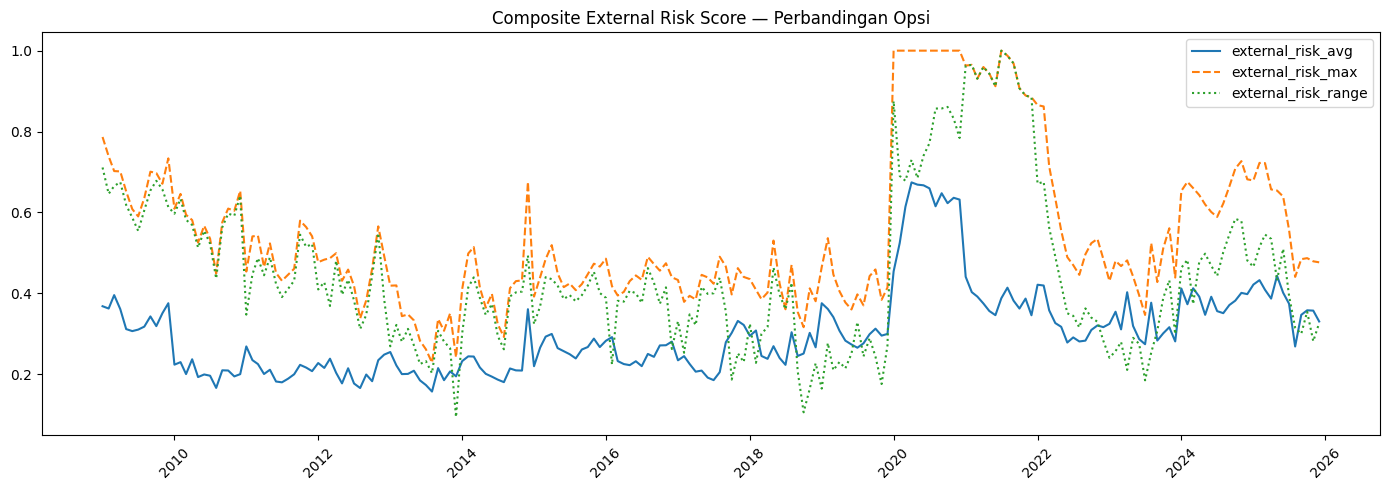

In [32]:
risk_components = [
    'gdelt_crisis_score',
    'economic_risk_score',
    'trend_risk_score',
    'disaster_risk_score',
]

assert all(c in df_ext.columns for c in risk_components), \
    f'Kolom hilang: {[c for c in risk_components if c not in df_ext.columns]}'

# Equal weight average — sinyal rata-rata semua dimensi
df_ext['external_risk_avg'] = df_ext[risk_components].mean(axis=1)

# Max of components — shock detector
df_ext['external_risk_max'] = df_ext[risk_components].max(axis=1)

# Range spread — divergensi antar komponen
df_ext['external_risk_range'] = (
    df_ext[risk_components].max(axis=1) - df_ext[risk_components].min(axis=1)
)

composite_cols = ['external_risk_avg', 'external_risk_max', 'external_risk_range']
print('=== Composite Features ===')
print(df_ext[composite_cols].describe().round(4))

fig, ax = plt.subplots(figsize=(14, 5))
for col, style in zip(composite_cols, ['-', '--', ':']):
    ax.plot(df_ext['date'], df_ext[col], linestyle=style, label=col, linewidth=1.5)
ax.set_title('Composite External Risk Score — Perbandingan Opsi')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### 1.6 Validasi & Korelasi


Total fitur baru: 11
Total kolom df_ext setelah FE: 42

Null per fitur baru:
gdelt_crisis_score_slope3m     2
disaster_risk_score_slope3m    2
economic_risk_score_slope3m    2
gdelt_crisis_score_zscore      5
disaster_risk_score_zscore     5
dtype: int64

=== Korelasi Antar Risk Components ===


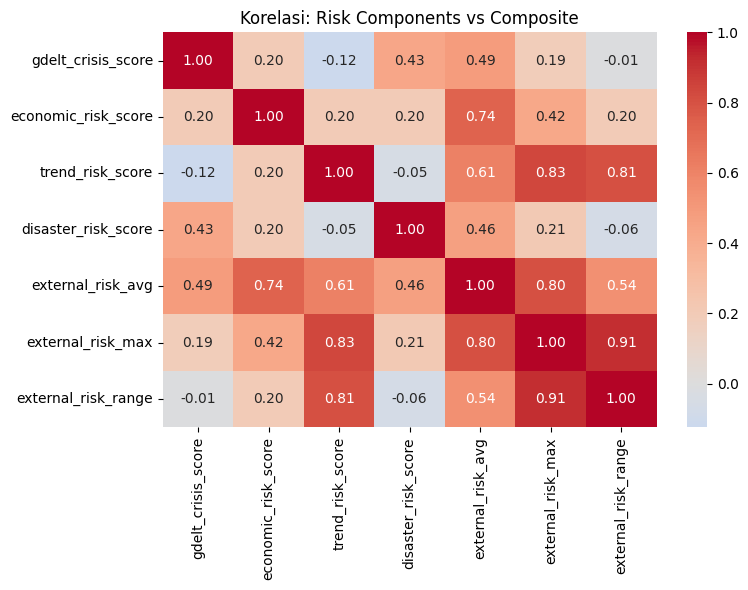

In [33]:
new_features_ext = (
    [f'{c}_ma3' for c in rolling_targets] +
    [f'{c}_slope3m' for c in rolling_targets] +
    [f'{c}_zscore' for c in zscore_targets] +
    ['external_risk_avg', 'external_risk_max', 'external_risk_range']
)

print(f'Total fitur baru: {len(new_features_ext)}')
print(f'Total kolom df_ext setelah FE: {len(df_ext.columns)}')

null_check = df_ext[new_features_ext].isnull().sum()
print('\nNull per fitur baru:')
print(null_check[null_check > 0])

print('\n=== Korelasi Antar Risk Components ===')
corr_df = df_ext[risk_components + composite_cols].corr().round(3)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Korelasi: Risk Components vs Composite')
plt.tight_layout()
plt.show()


### 1.7 Export `combined_additional_features_engineered_new.csv`


In [34]:
cols_to_keep = (
    ['date'] +
    risk_components +
    new_features_ext
)

df_ext_export = df_ext[cols_to_keep]
df_ext_export.to_csv('../data/processed/combined_additional_features_engineered_new.csv', index=False)

print(f'✓ Tersimpan: combined_additional_features_engineered_new.csv')
print(f'  Shape: {df_ext_export.shape}')
print(f'  Kolom ({len(df_ext_export.columns)}): {df_ext_export.columns.tolist()}')


✓ Tersimpan: combined_additional_features_engineered_new.csv
  Shape: (204, 16)
  Kolom (16): ['date', 'gdelt_crisis_score', 'economic_risk_score', 'trend_risk_score', 'disaster_risk_score', 'gdelt_crisis_score_ma3', 'disaster_risk_score_ma3', 'economic_risk_score_ma3', 'gdelt_crisis_score_slope3m', 'disaster_risk_score_slope3m', 'economic_risk_score_slope3m', 'gdelt_crisis_score_zscore', 'disaster_risk_score_zscore', 'external_risk_avg', 'external_risk_max', 'external_risk_range']


---
## Section 2 — Load Semua Data Processed
> Backbone timeline: 192 bulan (2009-01 → 2024-12) dari `wisman_clean.csv`.


In [35]:
# Load wisman gabungan
wisman = pd.read_csv('../data/processed/wisman_clean.csv')
wisman['month'] = pd.PeriodIndex(wisman['month'], freq='M')
print(f'wisman: {wisman.shape}, dari {wisman["month"].min()} hingga {wisman["month"].max()}')

# Load wisnus
wisnus = pd.read_csv('../data/processed/wisnus_clean.csv')
wisnus['month'] = pd.PeriodIndex(wisnus['month'], freq='M')
print(f'wisnus: {wisnus.shape}, dari {wisnus["month"].min()} hingga {wisnus["month"].max()}')

# Load kurs USD/IDR
monthly_usd = pd.read_csv('../data/processed/monthly_usd.csv')
monthly_usd['month'] = pd.PeriodIndex(monthly_usd['month'], freq='M')
print(f'monthly_usd: {monthly_usd.shape}')

# Load TPK
tpk = pd.read_csv('../data/processed/tpk_clean.csv')
tpk['month'] = pd.PeriodIndex(tpk['month'], freq='M')
print(f'tpk: {tpk.shape}')

# Load lama menginap  [BARU — ditambahkan dari NB02 sesi ini]
lama = pd.read_csv('../data/processed/lama_menginap_clean.csv')
lama['month'] = pd.PeriodIndex(lama['month'], freq='M')
print(f'lama_menginap: {lama.shape}')

# Load inflasi
inflasi = pd.read_csv('../data/processed/inflasi_clean.csv')
inflasi['month'] = pd.PeriodIndex(inflasi['month'], freq='M')
print(f'inflasi: {inflasi.shape}')

# Load World Bank economic index
# ⚠ File tersimpan dengan index kolom — gunakan index_col=0
wb = pd.read_csv('../data/processed/wb_monthly_economic.csv', index_col=0)
wb['month'] = pd.PeriodIndex(wb.index, freq='M') if wb.index.dtype == 'O' else pd.PeriodIndex(wb['month'], freq='M')
# Fallback: jika kolom month tidak ada di index, coba buat dari index
if 'month' not in wb.columns:
    wb = wb.reset_index()
    wb.rename(columns={'index': 'month'}, inplace=True)
    wb['month'] = pd.PeriodIndex(wb['month'], freq='M')
print(f'wb_economic: {wb.shape}, kolom: {wb.columns.tolist()}')

# Load monthly_sentiment
monthly_sentiment = pd.read_csv('../data/processed/monthly_sentiment.csv')
monthly_sentiment['month'] = pd.PeriodIndex(monthly_sentiment['month'], freq='M')
print(f'monthly_sentiment: {monthly_sentiment.shape}, {monthly_sentiment["month"].min()} -> {monthly_sentiment["month"].max()}')

# Load sentiment_stats (fallback untuk bulan tanpa review)
sentiment_stats = pd.read_csv('../data/processed/sentiment_stats.csv')
print(f'sentiment_stats (fallback): {sentiment_stats.shape}')

# Load wisman Bali vs Indonesia tahunan
wisman_indo = pd.read_csv('../data/processed/wisman_vs_indonesia_clean.csv')
print(f'wisman_indo: {wisman_indo.shape}, tahun {wisman_indo["tahun"].min()}-{wisman_indo["tahun"].max()}')

# Load External Risk (output Section 1 — wajib sudah dijalankan)
external_risk = pd.read_csv('../data/processed/combined_additional_features_engineered_new.csv')
external_risk['date'] = pd.to_datetime(external_risk['date'])
# ⚠ File tidak punya kolom month — buat dari date
external_risk['month'] = external_risk['date'].dt.to_period('M')
print(f'external_risk: {external_risk.shape}, dari {external_risk["month"].min()} hingga {external_risk["month"].max()}')

print('\n✓ Semua data berhasil dimuat!')


wisman: (208, 3), dari 2009-01 hingga 2026-04
wisnus: (264, 3), dari 2004-01 hingga 2025-12
monthly_usd: (180, 2)
tpk: (315, 4)
lama_menginap: (204, 4)
inflasi: (204, 3)
wb_economic: (204, 4), kolom: ['economic_index', 'economic_risk_score', 'wb_is_imputed', 'month']
monthly_sentiment: (169, 8), 2009-05 -> 2026-05
sentiment_stats (fallback): (1, 5)
wisman_indo: (57, 4), tahun 1969-2025
external_risk: (204, 17), dari 2009-01 hingga 2025-12

✓ Semua data berhasil dimuat!


## Section 3 — Sinkronisasi Timeline & Merge Semua Dataset


In [36]:
# Backbone: 192 bulan dari wisman
final_df = wisman[['month', 'wisman']].copy()
print(f'Backbone timeline: {len(final_df)} baris')

# Merge wisnus
final_df = final_df.merge(wisnus[['month', 'wisnus']], on='month', how='left')

# Merge kurs USD/IDR
final_df = final_df.merge(monthly_usd[['month', 'usd_idr_avg']], on='month', how='left')

# Merge TPK
final_df = final_df.merge(
    tpk[['month', 'tpk_bintang', 'tpk_non_bintang']],
    on='month', how='left'
)

# Merge Lama Menginap  [BARU]
final_df = final_df.merge(
    lama[['month', 'lama_menginap_bintang', 'lama_menginap_non_bintang']],
    on='month', how='left'
)

# Merge inflasi
final_df = final_df.merge(inflasi[['month', 'inflasi_processed']], on='month', how='left')

# Merge wisman Bali vs Indonesia (data tahunan — join by tahun)
final_df['tahun'] = final_df['month'].dt.year
final_df = final_df.merge(
    wisman_indo[['tahun', 'indonesia_total', 'bali_share_pct']],
    on='tahun', how='left'
)
final_df.drop(columns=['tahun'], inplace=True)

# Merge monthly_sentiment
final_df = final_df.merge(
    monthly_sentiment[['month', 'avg_sentiment', 'pct_negative', 'pct_positive', 'pct_neutral', 'review_count', 'avg_rating']],
    on='month', how='left'
)

# Isi bulan tanpa data review dengan nilai global
global_avg_sentiment = sentiment_stats['avg_sentiment'].values[0]
global_pct_negative  = sentiment_stats['pct_negative'].values[0]
global_pct_positive  = sentiment_stats['pct_positive'].values[0]
global_pct_neutral   = sentiment_stats['pct_neutral'].values[0]
final_df['avg_sentiment'].fillna(global_avg_sentiment, inplace=True)
final_df['pct_negative'].fillna(global_pct_negative, inplace=True)
final_df['pct_positive'].fillna(global_pct_positive, inplace=True)
final_df['pct_neutral'].fillna(global_pct_neutral, inplace=True)

# Rename agar konsisten dengan kode downstream
final_df.rename(columns={
    'avg_sentiment': 'avg_sentiment_monthly',
    'pct_negative':  'pct_negative_monthly',
    'pct_positive':  'pct_positive_monthly',
    'pct_neutral':   'pct_neutral_monthly',
}, inplace=True)

print('Monthly sentiment coverage:')
print(f'  Bulan dengan data review nyata: {final_df["review_count"].notna().sum()}/192')
print(f'  Bulan fallback (tanpa review): {final_df["review_count"].isna().sum()}/192')

# Merge External Risk Score + seluruh komponen pembentuknya
final_df = final_df.merge(
    external_risk[[
        'month',
        'gdelt_crisis_score', 'economic_risk_score',
        'trend_risk_score', 'disaster_risk_score',
        'external_risk_avg', 'external_risk_max', 'external_risk_range'
    ]],
    on='month', how='left'
)

print(f'\nShape setelah merge: {final_df.shape}')
print('\nMissing values per kolom:')
print(final_df.isnull().sum().to_string())


Backbone timeline: 208 baris
Monthly sentiment coverage:
  Bulan dengan data review nyata: 168/192
  Bulan fallback (tanpa review): 40/192

Shape setelah merge: (208, 24)

Missing values per kolom:
month                         0
wisman                        0
wisnus                        4
usd_idr_avg                  28
tpk_bintang                   1
tpk_non_bintang              76
lama_menginap_bintang         4
lama_menginap_non_bintang    76
inflasi_processed             4
indonesia_total               4
bali_share_pct                4
avg_sentiment_monthly         0
pct_negative_monthly          0
pct_positive_monthly          0
pct_neutral_monthly           0
review_count                 40
avg_rating                   58
gdelt_crisis_score            4
economic_risk_score           4
trend_risk_score              4
disaster_risk_score           4
external_risk_avg             4
external_risk_max             4
external_risk_range           4


### 3.1 Handle Missing Values


In [37]:
cols_to_ffill = [
    'usd_idr_avg', 'tpk_bintang', 'tpk_non_bintang',
    'lama_menginap_bintang', 'lama_menginap_non_bintang',
    'inflasi_processed', 'bali_share_pct', 'indonesia_total',
    'external_risk_avg', 'external_risk_max', 'external_risk_range'
]
for col in cols_to_ffill:
    if col in final_df.columns:
        before = final_df[col].isnull().sum()
        final_df[col] = final_df[col].ffill().bfill()
        after = final_df[col].isnull().sum()
        print(f'  {col}: {before} -> {after} missing')

# Interpolasi wisnus
if 'wisnus' in final_df.columns:
    final_df['wisnus'] = final_df['wisnus'].interpolate(method='linear')

print('\nMissing values setelah handle:')
print(final_df.isnull().sum().to_string())


  usd_idr_avg: 28 -> 0 missing
  tpk_bintang: 1 -> 0 missing
  tpk_non_bintang: 76 -> 0 missing
  lama_menginap_bintang: 4 -> 0 missing
  lama_menginap_non_bintang: 76 -> 0 missing
  inflasi_processed: 4 -> 0 missing
  bali_share_pct: 4 -> 0 missing
  indonesia_total: 4 -> 0 missing
  external_risk_avg: 4 -> 0 missing
  external_risk_max: 4 -> 0 missing
  external_risk_range: 4 -> 0 missing

Missing values setelah handle:
month                         0
wisman                        0
wisnus                        0
usd_idr_avg                   0
tpk_bintang                   0
tpk_non_bintang               0
lama_menginap_bintang         0
lama_menginap_non_bintang     0
inflasi_processed             0
indonesia_total               0
bali_share_pct                0
avg_sentiment_monthly         0
pct_negative_monthly          0
pct_positive_monthly          0
pct_neutral_monthly           0
review_count                 40
avg_rating                   58
gdelt_crisis_score            

## Section 4 — Feature Engineering
> Semua feature engineering dilakukan inline (konsisten, tanpa duplikasi dengan `build_features()`).
> Fungsi `build_features()` di Section 4c hanya untuk pipeline otomatis — tidak dijalankan ulang di sini.


### 4a. Feature Engineering Utama


In [38]:
new_features = []

# 1. Growth rate wisatawan MoM
final_df['wisman_growth_mom'] = final_df['wisman'].pct_change()
final_df['wisnus_growth_mom'] = final_df['wisnus'].pct_change() if 'wisnus' in final_df.columns else 0
new_features += ['wisman_growth_mom', 'wisnus_growth_mom']

# 2. Growth rate YoY (12 bulan)
final_df['wisman_growth_yoy'] = final_df['wisman'].pct_change(periods=12)
new_features.append('wisman_growth_yoy')

# 3. Rolling average 3 & 6 bulan
final_df['wisman_ma3'] = final_df['wisman'].rolling(3).mean()
final_df['wisman_ma6'] = final_df['wisman'].rolling(6).mean()
new_features += ['wisman_ma3', 'wisman_ma6']

# 4. Volatilitas & perubahan kurs USD
if 'usd_idr_avg' in final_df.columns:
    final_df['usd_volatility_3m'] = final_df['usd_idr_avg'].rolling(3).std()
    final_df['usd_change_mom'] = final_df['usd_idr_avg'].pct_change()
    new_features += ['usd_volatility_3m', 'usd_change_mom']

# 5. Z-score anomali kunjungan
rolling_mean_12m = final_df['wisman'].rolling(12).mean()
rolling_std_12m  = final_df['wisman'].rolling(12).std()
final_df['wisman_zscore'] = (final_df['wisman'] - rolling_mean_12m) / rolling_std_12m
final_df['is_anomaly']    = (final_df['wisman_zscore'] < -2).astype(int)
new_features += ['wisman_zscore', 'is_anomaly']

# 6. Sesonalitas
final_df['month_num'] = final_df['month'].dt.month
final_df['is_peak_season'] = final_df['month_num'].isin([7, 8, 12]).astype(int)
new_features += ['month_num', 'is_peak_season']

# 7. Label periode krisis COVID
final_df['month_dt'] = final_df['month'].dt.to_timestamp()
final_df['is_covid_period'] = (
    (final_df['month_dt'] >= '2020-03-01') &
    (final_df['month_dt'] <= '2021-12-31')
).astype(int)
new_features.append('is_covid_period')

# 8. Bali share perubahan
if 'bali_share_pct' in final_df.columns:
    final_df['bali_share_change'] = final_df['bali_share_pct'].diff()
    new_features.append('bali_share_change')

# 9. TPK change & rolling
if 'tpk_bintang' in final_df.columns:
    final_df['tpk_change_mom'] = final_df['tpk_bintang'].diff()
    final_df['tpk_ma3'] = final_df['tpk_bintang'].rolling(3).mean()
    new_features += ['tpk_change_mom', 'tpk_ma3']

# 10. Pre-COVID baseline
precovid_mean = final_df[final_df['month'].dt.year.between(2017, 2019)]['wisman'].mean()
final_df['wisman_precovid_mean'] = precovid_mean
new_features.append('wisman_precovid_mean')

print('Feature engineering selesai!')
print('Fitur baru yang dibuat:')
for f in new_features:
    if f in final_df.columns:
        print(f'  {f}')


Feature engineering selesai!
Fitur baru yang dibuat:
  wisman_growth_mom
  wisnus_growth_mom
  wisman_growth_yoy
  wisman_ma3
  wisman_ma6
  usd_volatility_3m
  usd_change_mom
  wisman_zscore
  is_anomaly
  month_num
  is_peak_season
  is_covid_period
  bali_share_change
  tpk_change_mom
  tpk_ma3
  wisman_precovid_mean


### 4b. Feature Engineering Lanjutan — Lag & Rolling Trend


In [39]:
# 11. Lag features
final_df['wisman_lag_1'] = final_df['wisman'].shift(1)
final_df['wisman_lag_3'] = final_df['wisman'].shift(3)
if 'tpk_bintang' in final_df.columns:
    final_df['tpk_lag_1'] = final_df['tpk_bintang'].shift(1)
if 'avg_sentiment_monthly' in final_df.columns:
    final_df['sentiment_lag_1'] = final_df['avg_sentiment_monthly'].shift(1)

# 12. Rolling trend direction (slope)
def rolling_slope(series, window=3):
    """Slope linear regression menggunakan polyfit, raw=True."""
    return series.rolling(window).apply(
        lambda x: float(np.polyfit(range(len(x)), x, 1)[0])
        if len(x) == window else np.nan,
        raw=True
    )

final_df['wisman_trend_3m'] = rolling_slope(final_df['wisman'], 3)
if 'avg_sentiment_monthly' in final_df.columns:
    final_df['sentiment_trend_3m'] = rolling_slope(final_df['avg_sentiment_monthly'], 3)
if 'usd_idr_avg' in final_df.columns:
    final_df['usd_trend_3m'] = rolling_slope(final_df['usd_idr_avg'], 3)

# 13. Regime features
final_df['is_postcovid'] = (
    (final_df['month_dt'] >= '2022-01-01') &
    (final_df['month_dt'] <= '2022-12-31')
).astype(int)

final_df['wisman_recovery_pct'] = (final_df['wisman'] / precovid_mean * 100).round(2)

lag_cols = [
    'wisman_lag_1', 'wisman_lag_3', 'tpk_lag_1', 'sentiment_lag_1',
    'wisman_trend_3m', 'sentiment_trend_3m', 'usd_trend_3m',
    'is_postcovid', 'wisman_recovery_pct'
]
print('=== Fitur Lag & Trend ===')
for c in lag_cols:
    if c in final_df.columns:
        non_null = final_df[c].notna().sum()
        print(f'  {c:30s}: {non_null}/{len(final_df)} non-null')


=== Fitur Lag & Trend ===
  wisman_lag_1                  : 207/208 non-null
  wisman_lag_3                  : 205/208 non-null
  tpk_lag_1                     : 207/208 non-null
  sentiment_lag_1               : 207/208 non-null
  wisman_trend_3m               : 206/208 non-null
  sentiment_trend_3m            : 206/208 non-null
  usd_trend_3m                  : 206/208 non-null
  is_postcovid                  : 208/208 non-null
  wisman_recovery_pct           : 208/208 non-null


### 4c. Fungsi `build_features()` — Untuk Pipeline Otomatis
> Fungsi ini **tidak dieksekusi di sini** (FE sudah dilakukan di 4a & 4b).
> Disimpan untuk diimpor oleh `update_pipeline.py` agar feature engineering bulanan
> menghasilkan kolom yang **persis sama** dengan notebook ini.


In [40]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Bangun seluruh fitur BaliGuard dari dataframe mentah.

    Kolom INPUT minimal:
      month (Period/str), wisman, usd_idr_avg, tpk_bintang,
      avg_sentiment_monthly, bali_share_pct, inflasi_processed

    Kolom OUTPUT: semua kolom input + seluruh fitur engineered.
    Dipanggil oleh update_pipeline.py setiap bulan.
    """
    df = df.copy()

    df['wisman_growth_mom'] = df['wisman'].pct_change()
    df['wisman_growth_yoy'] = df['wisman'].pct_change(periods=12)
    if 'wisnus' in df.columns:
        df['wisnus_growth_mom'] = df['wisnus'].pct_change()

    df['wisman_ma3'] = df['wisman'].rolling(3).mean()
    df['wisman_ma6'] = df['wisman'].rolling(6).mean()

    if 'usd_idr_avg' in df.columns:
        df['usd_volatility_3m'] = df['usd_idr_avg'].rolling(3).std()
        df['usd_change_mom']    = df['usd_idr_avg'].pct_change()

    rm12 = df['wisman'].rolling(12).mean()
    rs12 = df['wisman'].rolling(12).std()
    df['wisman_zscore'] = (df['wisman'] - rm12) / rs12
    df['is_anomaly']    = (df['wisman_zscore'] < -2).astype(int)

    month_series = df['month']
    if hasattr(month_series.iloc[0], 'month'):
        df['month_num']      = month_series.apply(lambda x: x.month)
        df['is_peak_season'] = month_series.apply(lambda x: x.month in [7, 8, 12]).astype(int)
        year_series          = month_series.apply(lambda x: x.year)
    else:
        dt = pd.to_datetime(month_series.astype(str))
        df['month_num']      = dt.dt.month
        df['is_peak_season'] = dt.dt.month.isin([7, 8, 12]).astype(int)
        year_series          = dt.dt.year

    dt_ts = pd.to_datetime(df['month'].astype(str))
    df['is_covid_period'] = ((dt_ts >= '2020-03-01') & (dt_ts <= '2021-12-31')).astype(int)
    df['is_postcovid']    = ((dt_ts >= '2022-01-01') & (dt_ts <= '2022-12-31')).astype(int)

    if 'bali_share_pct' in df.columns:
        df['bali_share_change'] = df['bali_share_pct'].diff()

    if 'tpk_bintang' in df.columns:
        df['tpk_change_mom'] = df['tpk_bintang'].diff()
        df['tpk_ma3']        = df['tpk_bintang'].rolling(3).mean()

    mask_precovid = year_series.between(2017, 2019)
    precovid_mean_ = df.loc[mask_precovid, 'wisman'].mean() if mask_precovid.sum() > 0 else df['wisman'].mean()
    df['wisman_precovid_mean'] = precovid_mean_
    df['wisman_recovery_pct']  = (df['wisman'] / precovid_mean_ * 100).round(2)

    df['wisman_lag_1'] = df['wisman'].shift(1)
    df['wisman_lag_3'] = df['wisman'].shift(3)
    if 'tpk_bintang' in df.columns:
        df['tpk_lag_1'] = df['tpk_bintang'].shift(1)
    if 'avg_sentiment_monthly' in df.columns:
        df['sentiment_lag_1'] = df['avg_sentiment_monthly'].shift(1)

    def _slope(series, window=3):
        return series.rolling(window).apply(
            lambda x: float(np.polyfit(range(len(x)), x, 1)[0])
            if len(x) == window else np.nan, raw=True)

    df['wisman_trend_3m'] = _slope(df['wisman'], 3)
    if 'avg_sentiment_monthly' in df.columns:
        df['sentiment_trend_3m'] = _slope(df['avg_sentiment_monthly'], 3)
    if 'usd_idr_avg' in df.columns:
        df['usd_trend_3m'] = _slope(df['usd_idr_avg'], 3)

    return df


print('✓ build_features() terdefinisi — siap diimpor oleh update_pipeline.py')


✓ build_features() terdefinisi — siap diimpor oleh update_pipeline.py


## Section 5 — Normalisasi Fitur


In [41]:
scaler = MinMaxScaler()

cols_to_normalize = ['wisman_growth_mom', 'wisman_growth_yoy', 'usd_volatility_3m', 'usd_change_mom']
cols_to_normalize = [c for c in cols_to_normalize if c in final_df.columns]

temp_norm = final_df[cols_to_normalize].copy()
for col in cols_to_normalize:
    q1  = temp_norm[col].quantile(0.05)
    q99 = temp_norm[col].quantile(0.95)
    temp_norm[col] = temp_norm[col].clip(q1, q99)

final_df[[f'{c}_norm' for c in cols_to_normalize]] = scaler.fit_transform(temp_norm.fillna(0))

print('✓ Normalisasi selesai!')
print('Kolom normalized:', [f'{c}_norm' for c in cols_to_normalize])


✓ Normalisasi selesai!
Kolom normalized: ['wisman_growth_mom_norm', 'wisman_growth_yoy_norm', 'usd_volatility_3m_norm', 'usd_change_mom_norm']


## Section 6 — Hitung Crisis Score
```
Crisis Score = 0.45 × component_tourism + 0.25 × component_economy
             + 0.20 × external_risk_score + 0.10 × component_sentiment
```


In [42]:
def compute_crisis_component_tourism(row):
    growth_score = 0.0
    if 'wisman_growth_mom_norm' in row.index and not pd.isna(row['wisman_growth_mom_norm']):
        growth_score = 1 - row['wisman_growth_mom_norm']
    zscore_score = 0.0
    if not pd.isna(row.get('wisman_zscore', np.nan)):
        zscore_raw = min(max(-row['wisman_zscore'], 0), 4)
        zscore_score = zscore_raw / 4
    return (growth_score * 0.6) + (zscore_score * 0.4)

def compute_crisis_component_economy(row):
    econ_score = 0.0
    if 'usd_volatility_3m_norm' in row.index and not pd.isna(row['usd_volatility_3m_norm']):
        econ_score += row['usd_volatility_3m_norm'] * 0.4
    if 'usd_change_mom_norm' in row.index and not pd.isna(row['usd_change_mom_norm']):
        econ_score += row['usd_change_mom_norm'] * 0.3
    if 'tpk_bintang' in row.index and not pd.isna(row.get('tpk_bintang')):
        tpk_score = max(0, (60 - row['tpk_bintang']) / 60)
        econ_score += tpk_score * 0.3
    return min(econ_score, 1.0)

def compute_crisis_component_sentiment(row):
    pct_neg  = row.get('pct_negative_monthly', 29.0)
    avg_sent = row.get('avg_sentiment_monthly', 0.22)
    neg_score  = pct_neg / 100.0
    sent_score = max(0, (0 - avg_sent) / 2 + 0.5)
    return min((neg_score * 0.6) + (sent_score * 0.4), 1.0)

print('✓ Fungsi crisis component siap!')


✓ Fungsi crisis component siap!


In [43]:
# Hitung komponen
final_df['crisis_component_tourism']  = final_df.apply(compute_crisis_component_tourism, axis=1)
final_df['crisis_component_economy']  = final_df.apply(compute_crisis_component_economy, axis=1)
final_df['crisis_component_sentiment'] = final_df.apply(compute_crisis_component_sentiment, axis=1)

# Dashboard indicators
final_df['physical_risk_score']        = final_df['disaster_risk_score']
final_df['media_risk_score']           = final_df['gdelt_crisis_score']
final_df['tourist_perception_score']   = final_df[['trend_risk_score', 'economic_risk_score']].mean(axis=1)
final_df['external_risk_score']        = final_df['external_risk_avg']

for col in ['physical_risk_score', 'media_risk_score', 'tourist_perception_score']:
    before = final_df[col].isnull().sum()
    final_df[col] = final_df[col].ffill()
    print(f'  {col}: {before} NaN → {final_df[col].isnull().sum()} NaN')

# Crisis Score komposit berbobot
WEIGHT_TOURISM   = 0.45
WEIGHT_ECONOMY   = 0.25
WEIGHT_EXTERNAL  = 0.20
WEIGHT_SENTIMENT = 0.10

final_df['crisis_score'] = (
    WEIGHT_TOURISM   * final_df['crisis_component_tourism'] +
    WEIGHT_ECONOMY   * final_df['crisis_component_economy'] +
    WEIGHT_EXTERNAL  * final_df['external_risk_score'] +
    WEIGHT_SENTIMENT * final_df['crisis_component_sentiment']
)
final_df['crisis_score_100'] = final_df['crisis_score'] * 100

print('✓ Crisis Score berhasil dihitung!')
print(f'  Min:  {final_df["crisis_score_100"].min():.1f}')
print(f'  Max:  {final_df["crisis_score_100"].max():.1f}')
print(f'  Mean: {final_df["crisis_score_100"].mean():.1f}')


  physical_risk_score: 4 NaN → 0 NaN
  media_risk_score: 4 NaN → 0 NaN
  tourist_perception_score: 4 NaN → 0 NaN
✓ Crisis Score berhasil dihitung!
  Min:  16.6
  Max:  77.0
  Mean: 34.0


In [44]:
# Threshold & labeling
THRESHOLD_KRISIS  = 60
THRESHOLD_SIAGA   = 45
THRESHOLD_WASPADA = 30

def label_crisis(row):
    score    = row['crisis_score_100']
    wisman_v = row['wisman']
    baseline = row.get('wisman_precovid_mean', 501206)
    if wisman_v < (baseline * 0.05):
        return 'KRISIS' if score >= THRESHOLD_KRISIS else 'SIAGA'
    if   score >= THRESHOLD_KRISIS:  return 'KRISIS'
    elif score >= THRESHOLD_SIAGA:   return 'SIAGA'
    elif score >= THRESHOLD_WASPADA: return 'WASPADA'
    else:                            return 'AMAN'

final_df['crisis_level'] = final_df.apply(label_crisis, axis=1)

print('=== CEK PERIODE COVID (harus dominan SIAGA/KRISIS) ===')
covid_check = final_df[
    (final_df['month'].dt.year >= 2020) &
    (final_df['month'].dt.year <= 2021)
][['month', 'wisman', 'crisis_score_100', 'crisis_level']]
print(covid_check.to_string())

print('\n=== DISTRIBUSI LEVEL KRISIS ===')
print(final_df['crisis_level'].value_counts().to_string())

print('\n=== CEK BULAN COVID YANG MASIH AMAN (seharusnya 0) ===')
covid_aman = final_df[
    (final_df['month'].dt.year >= 2020) &
    (final_df['month'].dt.year <= 2021) &
    (final_df['crisis_level'] == 'AMAN')
]
print(f'Jumlah: {len(covid_aman)} bulan')
if len(covid_aman) > 0:
    print(f'⚠ Threshold perlu ditinjau!')
    print(covid_aman[['month','crisis_score_100','crisis_level']].to_string())
else:
    print('✓ Semua periode COVID masuk SIAGA/KRISIS — crisis score valid!')


=== CEK PERIODE COVID (harus dominan SIAGA/KRISIS) ===
       month  wisman  crisis_score_100 crisis_level
132  2020-01  536611         34.978371      WASPADA
133  2020-02  364639         59.719425        SIAGA
134  2020-03  167461         75.327390       KRISIS
135  2020-04     379         77.013790       KRISIS
136  2020-05      36         67.336559       KRISIS
137  2020-06      45         48.508819        SIAGA
138  2020-07      16         71.528494       KRISIS
139  2020-08      12         63.405972       KRISIS
140  2020-09       8         60.677177       KRISIS
141  2020-10      63         27.524947        SIAGA
142  2020-11      53         54.848788        SIAGA
143  2020-12     150         32.528238        SIAGA
144  2021-01      10         49.786206        SIAGA
145  2021-02      12         32.556793        SIAGA
146  2021-03       3         58.062487        SIAGA
147  2021-04       9         29.767594        SIAGA
148  2021-05       8         42.068705        SIAGA
149  2021

## Section 7 — Visualisasi Crisis Score Timeline


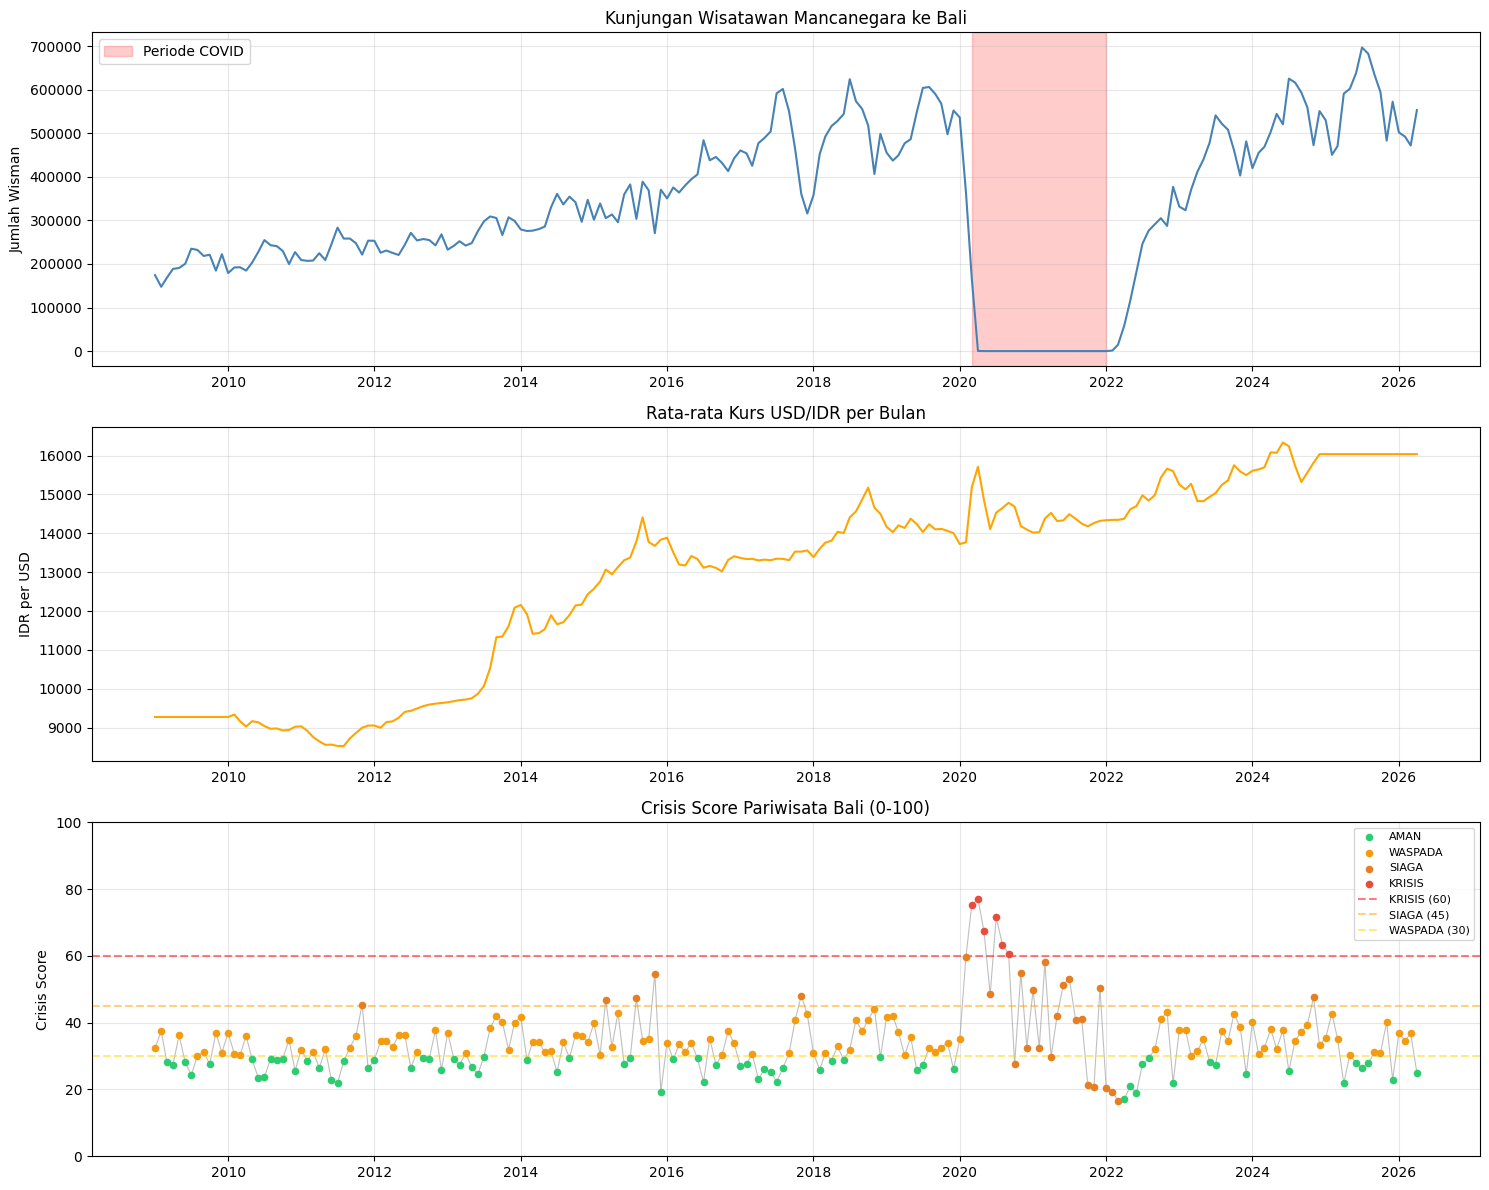

✓ Plot disimpan ke ../reports/figures/crisis_score_timeline.png


In [45]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

plot_df = final_df.dropna(subset=['crisis_score_100']).copy()
plot_df['date'] = plot_df['month'].dt.to_timestamp()

# Wisman
axes[0].plot(plot_df['date'], plot_df['wisman'], color='steelblue', linewidth=1.5)
axes[0].axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'),
                alpha=0.2, color='red', label='Periode COVID')
axes[0].set_title('Kunjungan Wisatawan Mancanegara ke Bali', fontsize=12)
axes[0].set_ylabel('Jumlah Wisman')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Kurs USD/IDR
if 'usd_idr_avg' in plot_df.columns:
    usd_data = plot_df.dropna(subset=['usd_idr_avg'])
    axes[1].plot(usd_data['date'], usd_data['usd_idr_avg'], color='orange', linewidth=1.5)
    axes[1].set_title('Rata-rata Kurs USD/IDR per Bulan', fontsize=12)
    axes[1].set_ylabel('IDR per USD')
    axes[1].grid(alpha=0.3)

# Crisis Score
level_colors = {'AMAN': '#2ecc71', 'WASPADA': '#f39c12', 'SIAGA': '#e67e22', 'KRISIS': '#e74c3c'}
for level, color in level_colors.items():
    mask = plot_df['crisis_level'] == level
    axes[2].scatter(plot_df.loc[mask, 'date'], plot_df.loc[mask, 'crisis_score_100'],
                    c=color, label=level, s=20, zorder=3)
axes[2].plot(plot_df['date'], plot_df['crisis_score_100'], color='gray', linewidth=0.8, alpha=0.5)
axes[2].axhline(THRESHOLD_KRISIS,  color='red',    linestyle='--', alpha=0.5, label=f'KRISIS ({THRESHOLD_KRISIS})')
axes[2].axhline(THRESHOLD_SIAGA,   color='orange', linestyle='--', alpha=0.5, label=f'SIAGA ({THRESHOLD_SIAGA})')
axes[2].axhline(THRESHOLD_WASPADA, color='gold',   linestyle='--', alpha=0.5, label=f'WASPADA ({THRESHOLD_WASPADA})')
axes[2].set_title('Crisis Score Pariwisata Bali (0-100)', fontsize=12)
axes[2].set_ylabel('Crisis Score')
axes[2].set_ylim(0, 100)
axes[2].legend(loc='upper right', fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
# ✅ Disimpan ke reports/figures/ (bukan data/processed/)
plt.savefig('../reports/figures/crisis_score_timeline.png', dpi=150)
plt.show()
print('✓ Plot disimpan ke ../reports/figures/crisis_score_timeline.png')


## Section 8 — Simpan Dataset Final


In [46]:
os.makedirs('../data/final', exist_ok=True)

output_cols = [
    'month',
    # Data mentah
    'wisman', 'wisnus',
    'usd_idr_avg',
    'tpk_bintang', 'tpk_non_bintang', 'tpk_change_mom', 'tpk_ma3',
    'lama_menginap_bintang', 'lama_menginap_non_bintang',  # [BARU]
    'inflasi_processed',
    'indonesia_total', 'bali_share_pct',
    'avg_sentiment_monthly', 'pct_negative_monthly', 'pct_positive_monthly', 'pct_neutral_monthly',
    # Feature engineering
    'wisman_growth_mom', 'wisnus_growth_mom', 'wisman_growth_yoy',
    'wisman_ma3', 'wisman_ma6',
    'wisman_zscore', 'is_anomaly',
    'usd_volatility_3m', 'usd_change_mom',
    'month_num', 'is_peak_season', 'is_covid_period', 'bali_share_change',
    'wisman_precovid_mean',
    # Lag & trend
    'wisman_lag_1', 'wisman_lag_3',
    'tpk_lag_1', 'sentiment_lag_1',
    'wisman_trend_3m', 'sentiment_trend_3m', 'usd_trend_3m',
    'is_postcovid', 'wisman_recovery_pct',
    # Crisis components
    'crisis_component_tourism', 'crisis_component_economy', 'crisis_component_sentiment',
    'external_risk_avg', 'external_risk_max', 'external_risk_range',
    'physical_risk_score', 'media_risk_score', 'tourist_perception_score', 'external_risk_score',
    # Crisis score final
    'crisis_score', 'crisis_score_100', 'crisis_level',
]

output_cols = [c for c in output_cols if c in final_df.columns]
final_output = final_df[output_cols].copy()

# Handle nilai inf
_num_cols = final_output.select_dtypes(include=[np.number]).columns
_inf_count = np.isinf(final_output[_num_cols].values).sum()
if _inf_count > 0:
    print(f'⚠ {_inf_count} nilai inf ditemukan -> diganti dengan median kolom')
    for _col in _num_cols:
        if np.isinf(final_output[_col]).any():
            _n = np.isinf(final_output[_col]).sum()
            final_output[_col] = final_output[_col].replace([np.inf, -np.inf], np.nan)
            final_output[_col] = final_output[_col].fillna(final_output[_col].median())
            print(f'   {_col}: {_n} inf -> diisi median')
else:
    print('✓ Tidak ada nilai inf di dataset')

# Simpan CSV
final_output.to_csv('../data/final/crisis_dataset_final.csv', index=False)

# Simpan Parquet (month dikonversi ke str karena Parquet tidak support PeriodIndex)
final_parquet = final_output.copy()
final_parquet['month'] = final_parquet['month'].astype(str)
final_parquet.to_parquet('../data/final/master_dataset_clean.parquet', index=False)

print(f'\n✓ CSV disimpan    : ../data/final/crisis_dataset_final.csv')
print(f'✓ Parquet disimpan: ../data/final/master_dataset_clean.parquet')
print(f'   Shape: {final_output.shape}')
print(f'   Kolom ({len(output_cols)}): {output_cols}')
print()
print('✓ Dataset FROZEN — siap untuk NB05 (Modeling) dan NB06 (LLM Narrative)')


⚠ 6 nilai inf ditemukan -> diganti dengan median kolom
   wisman_growth_mom: 2 inf -> diisi median
   wisman_growth_yoy: 4 inf -> diisi median

✓ CSV disimpan    : ../data/final/crisis_dataset_final.csv
✓ Parquet disimpan: ../data/final/master_dataset_clean.parquet
   Shape: (208, 53)
   Kolom (53): ['month', 'wisman', 'wisnus', 'usd_idr_avg', 'tpk_bintang', 'tpk_non_bintang', 'tpk_change_mom', 'tpk_ma3', 'lama_menginap_bintang', 'lama_menginap_non_bintang', 'inflasi_processed', 'indonesia_total', 'bali_share_pct', 'avg_sentiment_monthly', 'pct_negative_monthly', 'pct_positive_monthly', 'pct_neutral_monthly', 'wisman_growth_mom', 'wisnus_growth_mom', 'wisman_growth_yoy', 'wisman_ma3', 'wisman_ma6', 'wisman_zscore', 'is_anomaly', 'usd_volatility_3m', 'usd_change_mom', 'month_num', 'is_peak_season', 'is_covid_period', 'bali_share_change', 'wisman_precovid_mean', 'wisman_lag_1', 'wisman_lag_3', 'tpk_lag_1', 'sentiment_lag_1', 'wisman_trend_3m', 'sentiment_trend_3m', 'usd_trend_3m', 'is_po

## Section 9 — Summary & Statistik Akhir


In [47]:
print('=' * 60)
print('RINGKASAN DATASET FINAL — EARLY WARNING SYSTEM BALI')
print('=' * 60)
print(f'Total periode data  : {len(final_output)} bulan')
print(f'Rentang waktu       : {final_output["month"].min()} hingga {final_output["month"].max()}')
print(f'Total kolom         : {len(output_cols)}')
print()
print('Distribusi Level Krisis:')
crisis_dist = final_output['crisis_level'].value_counts()
for level, count in crisis_dist.items():
    emoji = {'AMAN': '🟢', 'WASPADA': '🟡', 'SIAGA': '🟠', 'KRISIS': '🔴'}.get(level, '⚪')
    pct = count / len(final_output) * 100
    print(f'  {emoji} {level}: {count} bulan ({pct:.1f}%)')

print()
print('Statistik Crisis Score (0–100):')
cs_stats = final_output['crisis_score_100'].describe()
print(f'  Min   : {cs_stats["min"]:.1f}')
print(f'  Max   : {cs_stats["max"]:.1f}')
print(f'  Mean  : {cs_stats["mean"]:.1f}')
print(f'  Std   : {cs_stats["std"]:.1f}')
print()
print('Langkah selanjutnya:')
print('  → NB05: Modeling Anomaly Detection + Classification (Isolation Forest + Random Forest)')
print('  → NB06: LLM Narrative Engine (Groq API)')


RINGKASAN DATASET FINAL — EARLY WARNING SYSTEM BALI
Total periode data  : 208 bulan
Rentang waktu       : 2009-01 hingga 2026-04
Total kolom         : 53

Distribusi Level Krisis:
  🟡 WASPADA: 108 bulan (51.9%)
  🟢 AMAN: 68 bulan (32.7%)
  🟠 SIAGA: 26 bulan (12.5%)
  🔴 KRISIS: 6 bulan (2.9%)

Statistik Crisis Score (0–100):
  Min   : 16.6
  Max   : 77.0
  Mean  : 34.0
  Std   : 9.7

Langkah selanjutnya:
  → NB05: Modeling Anomaly Detection + Classification (Isolation Forest + Random Forest)
  → NB06: LLM Narrative Engine (Groq API)


### 9.1 Heatmap Korelasi Antar Fitur


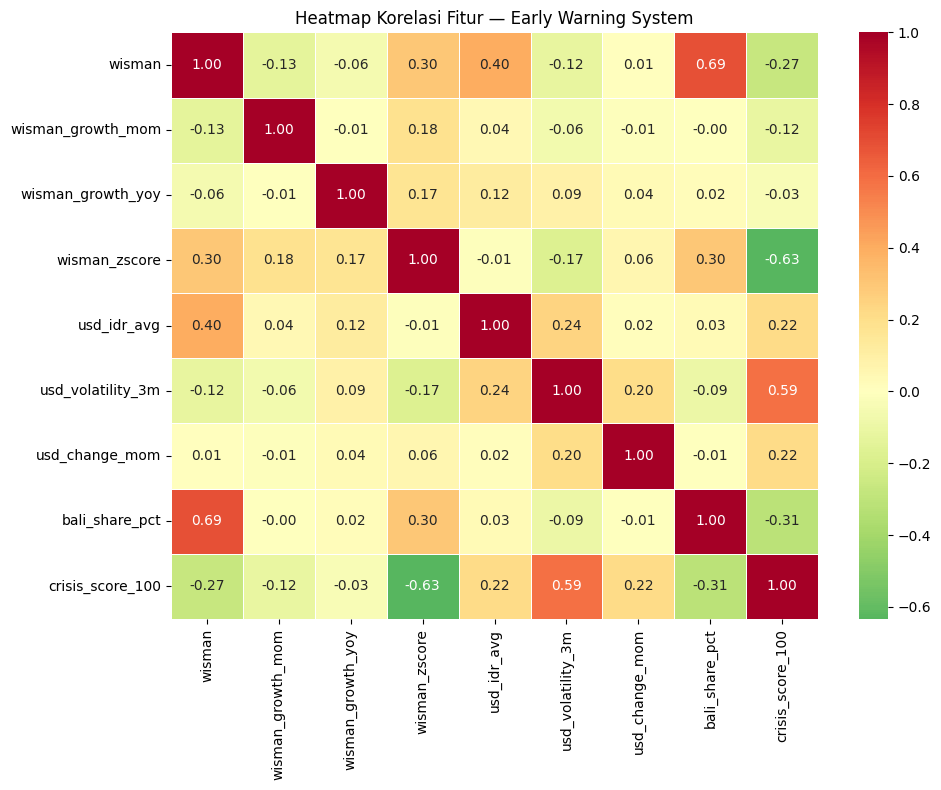

✓ Heatmap disimpan ke ../reports/figures/feature_correlation_heatmap.png


In [48]:
numeric_cols = [
    'wisman', 'wisman_growth_mom', 'wisman_growth_yoy', 'wisman_zscore',
    'usd_idr_avg', 'usd_volatility_3m', 'usd_change_mom',
    'bali_share_pct', 'crisis_score_100'
]
numeric_cols = [c for c in numeric_cols if c in final_output.columns]

corr_matrix = final_output[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0, linewidths=0.5)
plt.title('Heatmap Korelasi Fitur — Early Warning System', fontsize=12)
plt.tight_layout()
# ✅ Disimpan ke reports/figures/ (bukan data/processed/)
plt.savefig('../reports/figures/feature_correlation_heatmap.png', dpi=150)
plt.show()
print('✓ Heatmap disimpan ke ../reports/figures/feature_correlation_heatmap.png')


### 9.2 Validasi Tail Data


In [49]:
print('=== 12 Bulan Terakhir — External Risk & Crisis Score ===')
print(final_df.tail(12)[['month', 'external_risk_avg', 'external_risk_score', 'crisis_score_100']].to_string())
# external_risk pada bulan-bulan terakhir harus bervariasi (bukan flat) jika data tersedia


=== 12 Bulan Terakhir — External Risk & Crisis Score ===
       month  external_risk_avg  external_risk_score  crisis_score_100
196  2025-05           0.443168             0.443168         30.401443
197  2025-06           0.401351             0.401351         27.871693
198  2025-07           0.374205             0.374205         26.452260
199  2025-08           0.268395             0.268395         27.813794
200  2025-09           0.346576             0.346576         31.185872
201  2025-10           0.357874             0.357874         30.881759
202  2025-11           0.357079             0.357079         40.184368
203  2025-12           0.330244             0.330244         22.918340
204  2026-01           0.330244             0.330244         36.820542
205  2026-02           0.330244             0.330244         34.590459
206  2026-03           0.330244             0.330244         36.790857
207  2026-04           0.330244             0.330244         24.961304


### 9.3 Backup CSV


In [50]:
shutil.copy(
    '../data/final/crisis_dataset_final.csv',
    '../data/final/crisis_dataset_final_BACKUP.csv'
)
print('✓ Backup selesai: crisis_dataset_final_BACKUP.csv')


✓ Backup selesai: crisis_dataset_final_BACKUP.csv


In [51]:
# ── HASIL VERIFIKASI NB04 — copy output ini ke Claude ──────────────────────
import json

summary = {}

# 1. Shape & rentang
summary['shape'] = list(final_output.shape)
summary['month_min'] = str(final_output['month'].min())
summary['month_max'] = str(final_output['month'].max())
summary['kolom'] = final_output.columns.tolist()

# 2. Distribusi crisis level
summary['crisis_distribution'] = final_output['crisis_level'].value_counts().to_dict()

# 3. Crisis score stats
cs = final_output['crisis_score_100'].describe().round(2)
summary['crisis_score_stats'] = cs.to_dict()

# 4. Cek COVID (2020-2021) — harus 0 bulan AMAN
covid = final_output[final_output['month'].astype(str).str[:4].isin(['2020','2021'])]
summary['covid_check'] = covid[['month','crisis_score_100','crisis_level']].assign(
    month=lambda x: x['month'].astype(str)
).to_dict(orient='records')

# 5. Missing values (hanya yang > 0)
mv = final_output.isnull().sum()
summary['missing_values'] = mv[mv > 0].to_dict()

# 6. Inf check
import numpy as np
num_cols = final_output.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(final_output[num_cols].values).sum()
summary['inf_count'] = int(inf_count)

# 7. Sample 5 baris awal & akhir
summary['head_5'] = final_output.head(5).assign(
    month=lambda x: x['month'].astype(str)
).to_dict(orient='records')
summary['tail_5'] = final_output.tail(5).assign(
    month=lambda x: x['month'].astype(str)
).to_dict(orient='records')

# 8. External risk tail (validasi bukan flat)
ext_tail = final_output.tail(12)[['month','external_risk_avg','external_risk_score','crisis_score_100']]
summary['external_risk_tail'] = ext_tail.assign(
    month=lambda x: x['month'].astype(str)
).round(4).to_dict(orient='records')

print(json.dumps(summary, indent=2, default=str))

{
  "shape": [
    208,
    53
  ],
  "month_min": "2009-01",
  "month_max": "2026-04",
  "kolom": [
    "month",
    "wisman",
    "wisnus",
    "usd_idr_avg",
    "tpk_bintang",
    "tpk_non_bintang",
    "tpk_change_mom",
    "tpk_ma3",
    "lama_menginap_bintang",
    "lama_menginap_non_bintang",
    "inflasi_processed",
    "indonesia_total",
    "bali_share_pct",
    "avg_sentiment_monthly",
    "pct_negative_monthly",
    "pct_positive_monthly",
    "pct_neutral_monthly",
    "wisman_growth_mom",
    "wisnus_growth_mom",
    "wisman_growth_yoy",
    "wisman_ma3",
    "wisman_ma6",
    "wisman_zscore",
    "is_anomaly",
    "usd_volatility_3m",
    "usd_change_mom",
    "month_num",
    "is_peak_season",
    "is_covid_period",
    "bali_share_change",
    "wisman_precovid_mean",
    "wisman_lag_1",
    "wisman_lag_3",
    "tpk_lag_1",
    "sentiment_lag_1",
    "wisman_trend_3m",
    "sentiment_trend_3m",
    "usd_trend_3m",
    "is_postcovid",
    "wisman_recovery_pct",
    "cri